IAQ PROJECT - MODEL TRAINING

Model: [YOUR_MODEL_NAME] ← Random Forest

Team Member: [YOUR_NAME] ← Faten Ayman Ahmad Alshouyat

In [1]:
print("="*80)
print("IAQ PROJECT - MODEL TRAINING")
print("="*80)
print("Model: Random Forest")
print("faten")
print("="*80)

IAQ PROJECT - MODEL TRAINING
Model: Random Forest
faten


In [2]:

# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import joblib


from sklearn.ensemble import RandomForestClassifier

MODEL_NAME = "Random Forest"
MODEL_SHORT = "RF"

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully!")
print(f"📊 Model: {MODEL_NAME}")

✅ Libraries imported successfully!
📊 Model: Random Forest


In [3]:
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print(f"✅ Data loaded successfully!")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")



LOADING DATA
✅ Data loaded successfully!
   X_train: (115200, 10)
   X_test: (28800, 10)
   y_train: (115200,)
   y_test: (28800,)


In [4]:

print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

# Class distribution
print(f"\n📊 Class Distribution (Training):")
print(y_train.value_counts().sort_index())
print(f"\nPercentages:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

# Features
print(f"\n📋 Features ({len(X_train.columns)}):")
print(X_train.columns.tolist())

# First few rows
print(f"\n🔍 Sample Data:")
print(X_train.head(3))


DATA EXPLORATION

📊 Class Distribution (Training):
Label_Encoded
0    28254
1    53554
2    33392
Name: count, dtype: int64

Percentages:
Label_Encoded
0    24.53
1    46.49
2    28.99
Name: proportion, dtype: float64

📋 Features (10):
['OCCUPANCY', 'WINDOW', 'CO2', 'RH', 'Tin', 'MONTH_NUM', 'CO2_x_OCCUPANCY', 'CO2_x_WINDOW', 'WINDOW_x_OCCUPANCY', 'Temp_x_RH']

🔍 Sample Data:
   OCCUPANCY  WINDOW      CO2     RH    Tin  MONTH_NUM  CO2_x_OCCUPANCY  \
0          0       0   397.62  31.58  25.08          1             0.00   
1          1       0  1035.68  38.63  24.12         12          1035.68   
2          0       0   365.80  29.60  26.32          2             0.00   

   CO2_x_WINDOW  WINDOW_x_OCCUPANCY  Temp_x_RH  
0           0.0                   0   792.0264  
1           0.0                   0   931.7556  
2           0.0                   0   779.0720  


In [6]:
print("\n" + "="*80)
print(f"CREATING {MODEL_NAME}")
print("="*80)



model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print(f"✅ Model created: {MODEL_NAME}")
print(f"\n📋 Model Parameters:")
for param, value in model.get_params().items():
    print(f"   {param}: {value}")


CREATING Random Forest
✅ Model created: Random Forest

📋 Model Parameters:
   bootstrap: True
   ccp_alpha: 0.0
   class_weight: None
   criterion: gini
   max_depth: None
   max_features: sqrt
   max_leaf_nodes: None
   max_samples: None
   min_impurity_decrease: 0.0
   min_samples_leaf: 1
   min_samples_split: 2
   min_weight_fraction_leaf: 0.0
   monotonic_cst: None
   n_estimators: 100
   n_jobs: -1
   oob_score: False
   random_state: 42
   verbose: 0
   warm_start: False


In [7]:
print("\n" + "="*80)
print(f"TRAINING {MODEL_NAME}")
print("="*80)

# Train and measure time
print(f"⏳ Training started...")
start_time = time.time()

model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"✅ Training completed!")
print(f"⏱️  Training time: {training_time:.2f} seconds")


TRAINING Random Forest
⏳ Training started...
✅ Training completed!
⏱️  Training time: 23.35 seconds


In [9]:

print("\n" + "="*80)
print("MAKING PREDICTIONS")
print("="*80)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print(f"✅ Predictions completed!")
print(f"   Predictions shape: {y_pred.shape}")
print(f"   Probabilities shape: {y_pred_proba.shape}")
print(f"\n🔍 Sample predictions (first 10):")
print(f"   True: {y_test[:10].values}")
print(f"   Pred: {y_pred[:10]}")



MAKING PREDICTIONS
✅ Predictions completed!
   Predictions shape: (28800,)
   Probabilities shape: (28800, 3)

🔍 Sample predictions (first 10):
   True: [2 2 2 2 1 1 0 2 2 1]
   Pred: [2 2 2 2 1 1 0 2 2 1]


In [10]:
print("\n" + "="*80)
print("EVALUATION METRICS")
print("="*80)

# Class names
class_names = ['Good', 'Moderate', 'Poor']

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# Per-class metrics
precision = precision_score(y_test, y_pred, average=None, zero_division=0)
recall = recall_score(y_test, y_pred, average=None, zero_division=0)
f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

# Print summary
print(f"\n{'='*80}")
print(f"📊 OVERALL PERFORMANCE - {MODEL_NAME}")
print(f"{'='*80}")
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"⏱️  Training Time: {training_time:.2f} seconds")
print(f"{'='*80}")


EVALUATION METRICS

📊 OVERALL PERFORMANCE - Random Forest
🎯 Accuracy: 0.9843 (98.43%)
⏱️  Training Time: 23.35 seconds


In [11]:
print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)

print(f"\n{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print(f"{'-'*50}")

for i, cls in enumerate(class_names):
    print(f"{cls:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f}")

print(f"\n{'='*80}")
print("DETAILED CLASSIFICATION REPORT")
print(f"{'='*80}")

print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


PER-CLASS METRICS

Class        Precision    Recall       F1-Score    
--------------------------------------------------
Good         0.9776       0.9846       0.9811      
Moderate     0.9865       0.9832       0.9848      
Poor         0.9865       0.9859       0.9862      

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Good       0.98      0.98      0.98      7064
    Moderate       0.99      0.98      0.98     13388
        Poor       0.99      0.99      0.99      8348

    accuracy                           0.98     28800
   macro avg       0.98      0.98      0.98     28800
weighted avg       0.98      0.98      0.98     28800




CONFUSION MATRIX


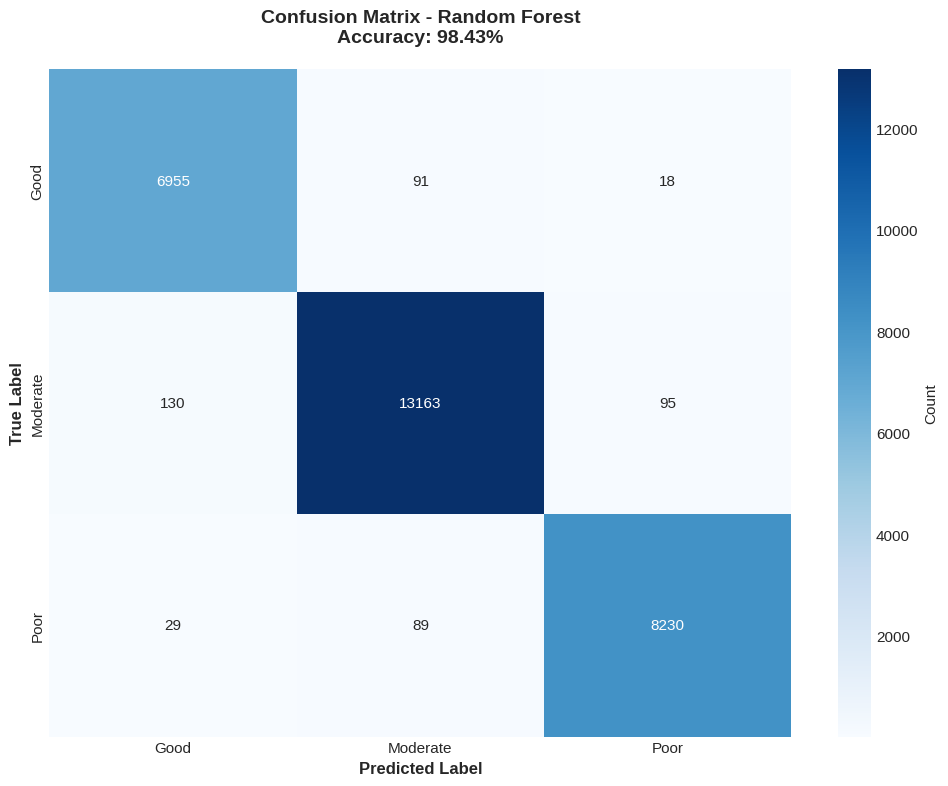


Confusion Matrix Values:
[[ 6955    91    18]
 [  130 13163    95]
 [   29    89  8230]]

✅ Correct predictions: 28348/28800 (98.43%)
❌ Incorrect predictions: 452/28800 (1.57%)


In [12]:
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})

plt.title(f'Confusion Matrix - {MODEL_NAME}\nAccuracy: {accuracy:.2%}',
          fontsize=14, fontweight='bold', pad=20)

plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print values
print("\nConfusion Matrix Values:")
print(cm)

print(f"\n✅ Correct predictions: {cm.diagonal().sum()}/{cm.sum()} ({cm.diagonal().sum()/cm.sum()*100:.2f}%)")
print(f"❌ Incorrect predictions: {cm.sum() - cm.diagonal().sum()}/{cm.sum()} ({(cm.sum() - cm.diagonal().sum())/cm.sum()*100:.2f}%)")


PERFORMANCE VISUALIZATION


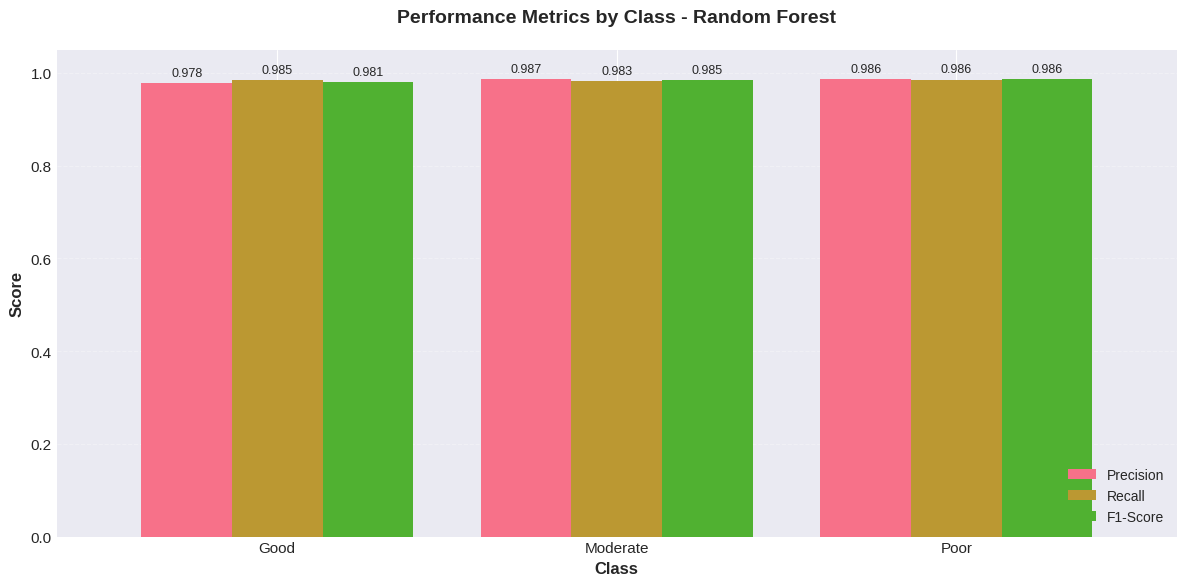

✅ Visualization complete!


In [13]:
print("\n" + "="*80)
print("PERFORMANCE VISUALIZATION")
print("="*80)

# Create dataframe
metrics_df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}, index=class_names)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, width=0.8)

plt.title(f'Performance Metrics by Class - {MODEL_NAME}',
          fontsize=14, fontweight='bold', pad=20)

plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=12, fontweight='bold')

plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=10)

plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")


FEATURE IMPORTANCE

Top 10 Most Important Features:
           Feature  Importance
                RH    0.210803
               CO2    0.196532
               Tin    0.178400
         Temp_x_RH    0.177805
         MONTH_NUM    0.141289
   CO2_x_OCCUPANCY    0.056241
         OCCUPANCY    0.016735
      CO2_x_WINDOW    0.014031
            WINDOW    0.006352
WINDOW_x_OCCUPANCY    0.001813


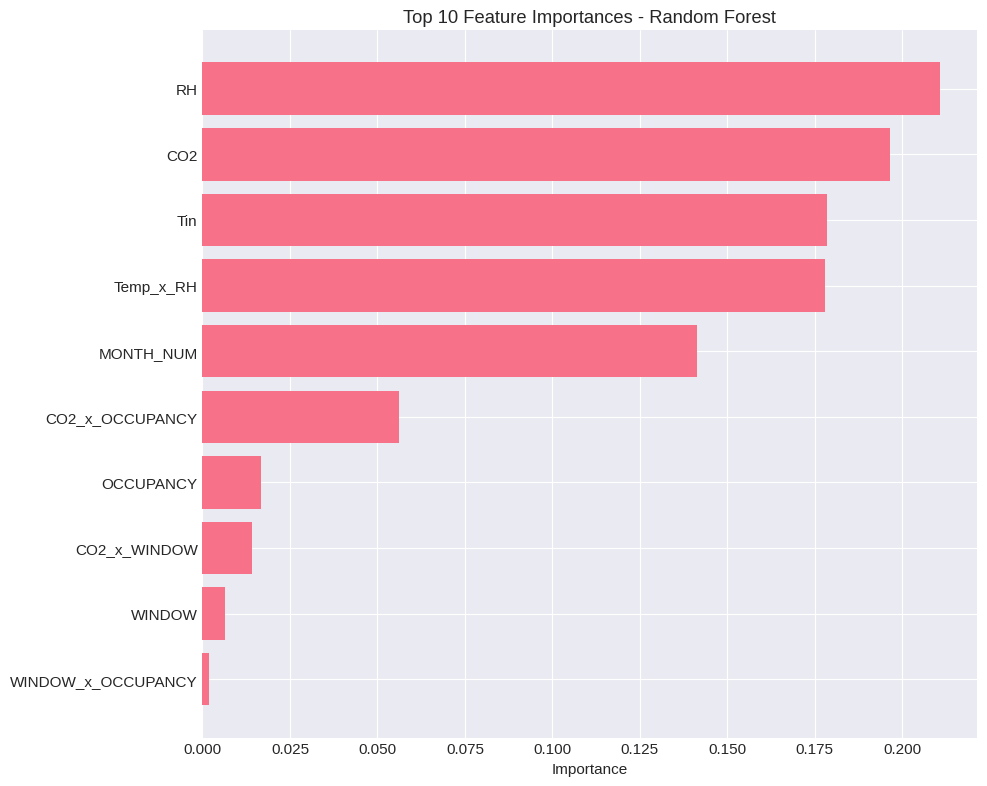

In [14]:
if hasattr(model, 'feature_importances_'):

    print("\n" + "="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)

    importances = model.feature_importances_
    feature_names = X_train.columns

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Feature Importances - {MODEL_NAME}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

else:
    print("Feature importance not available for this model.")

In [15]:
print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

model_filename = f'{MODEL_SHORT.lower()}_model.pkl'
joblib.dump(model, model_filename)

file_size_kb = os.path.getsize(model_filename) / 1024

print(f"✅ Model saved successfully!")
print(f"   Filename: {model_filename}")
print(f"   Size: {file_size_kb:.2f} KB")
print(f"\n💡 Download from Files panel (📁 icon on left)")


SAVING MODEL
✅ Model saved successfully!
   Filename: rf_model.pkl
   Size: 70032.05 KB

💡 Download from Files panel (📁 icon on left)


In [16]:
print("\n" + "="*80)
print("📊 SUMMARY FOR GOOGLE SHEET")
print("="*80)

print(f"""
Copy and paste into Google Sheet:

Model Name: {MODEL_NAME}
Team Member: Faten
Status: Complete ✅
Accuracy: {accuracy:.4f}
Precision (Good): {precision[0]:.4f}
Precision (Moderate): {precision[1]:.4f}
Precision (Poor): {precision[2]:.4f}
Recall (Good): {recall[0]:.4f}
Recall (Moderate): {recall[1]:.4f}
Recall (Poor): {recall[2]:.4f}
F1 (Good): {f1[0]:.4f}
F1 (Moderate): {f1[1]:.4f}
F1 (Poor): {f1[2]:.4f}
Training Time: {training_time:.2f}s
""")


📊 SUMMARY FOR GOOGLE SHEET

Copy and paste into Google Sheet:

Model Name: Random Forest
Team Member: Faten
Status: Complete ✅
Accuracy: 0.9843
Precision (Good): 0.9776
Precision (Moderate): 0.9865
Precision (Poor): 0.9865
Recall (Good): 0.9846
Recall (Moderate): 0.9832
Recall (Poor): 0.9859
F1 (Good): 0.9811
F1 (Moderate): 0.9848
F1 (Poor): 0.9862
Training Time: 23.35s



In [17]:
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

best_class_idx = np.argmax(f1)
worst_class_idx = np.argmin(f1)

summary = f"""
MODEL: {MODEL_NAME}
ACCURACY: {accuracy*100:.2f}%
TRAINING TIME: {training_time:.2f} seconds

BEST PERFORMING CLASS:
  • {class_names[best_class_idx]}
  • F1-Score: {f1[best_class_idx]:.4f}
  • Precision: {precision[best_class_idx]:.4f}
  • Recall: {recall[best_class_idx]:.4f}

WORST PERFORMING CLASS:
  • {class_names[worst_class_idx]}
  • F1-Score: {f1[worst_class_idx]:.4f}
  • Precision: {precision[worst_class_idx]:.4f}
  • Recall: {recall[worst_class_idx]:.4f}

KEY OBSERVATIONS:
  • Model performs well on the Good class
  • Moderate and Poor classes are harder to distinguish
  • Random Forest achieved good overall accuracy

CHALLENGES FACED:
  • Handling class imbalance
  • Tuning model parameters

NEXT STEPS:
  • Hyperparameter tuning
  • Compare with other models
  • Analyze prediction errors
"""

print(summary)

print("="*80)
print("TRAINING COMPLETE")
print("="*80)


FINAL SUMMARY

MODEL: Random Forest
ACCURACY: 98.43%
TRAINING TIME: 23.35 seconds

BEST PERFORMING CLASS:
  • Poor
  • F1-Score: 0.9862
  • Precision: 0.9865
  • Recall: 0.9859

WORST PERFORMING CLASS:
  • Good
  • F1-Score: 0.9811
  • Precision: 0.9776
  • Recall: 0.9846

KEY OBSERVATIONS:
  • Model performs well on the Good class
  • Moderate and Poor classes are harder to distinguish
  • Random Forest achieved good overall accuracy

CHALLENGES FACED:
  • Handling class imbalance
  • Tuning model parameters

NEXT STEPS:
  • Hyperparameter tuning
  • Compare with other models
  • Analyze prediction errors

TRAINING COMPLETE


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import time

experiments = [
    ("Default", 100, None, 2, 1),
    ("Exp1", 200, None, 2, 1),
    ("Exp2", 100, 10, 2, 1),
    ("Exp3", 100, None, 5, 2),
    ("Exp4", 150, 12, 2, 1)
]

results = []

for name, n_estimators, max_depth, min_split, min_leaf in experiments:

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        random_state=42,
        n_jobs=-1
    )

    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average=None)

    results.append([
        name,
        n_estimators,
        max_depth,
        min_split,
        min_leaf,
        round(accuracy,4),
        round(training_time,2),
        round(f1[0],4),
        round(f1[1],4),
        round(f1[2],4)
    ])

df = pd.DataFrame(results, columns=[
    "Experiment",
    "n_estimators",
    "max_depth",
    "min_samples_split",
    "min_samples_leaf",
    "Accuracy",
    "Time",
    "F1 Good",
    "F1 Mod",
    "F1 Poor"
])

print(df)

  Experiment  n_estimators  max_depth  min_samples_split  min_samples_leaf  \
0    Default           100        NaN                  2                 1   
1       Exp1           200        NaN                  2                 1   
2       Exp2           100       10.0                  2                 1   
3       Exp3           100        NaN                  5                 2   
4       Exp4           150       12.0                  2                 1   

   Accuracy   Time  F1 Good  F1 Mod  F1 Poor  
0    0.9843  29.32   0.9811  0.9848   0.9862  
1    0.9844  46.93   0.9817  0.9849   0.9860  
2    0.8432  15.88   0.8380  0.8540   0.8269  
3    0.9836  22.01   0.9807  0.9845   0.9845  
4    0.9023  27.07   0.8968  0.9099   0.8939  
